# PA3b: Sentiment classification
## Group 38

**Group Members:**
 - Sezin Kokum Mutludogan
 - Priyanka Machchhar 

### Preparing the data

In the below cells, we read the data and made the preprocessing to prepare it for model training.

In [2]:
import pandas as pd

df_gold_data = pd.read_csv('gold_train.csv', sep='\t')
df_gold_data.head()

,sentiment,text
0,neutral,There's so much misconception on Islam rn so s...
1,neutral,@Mr_Rondeau You should try Iron Maiden at abou...
2,neutral,Going to #FantasticFour tomorrow. Half expecti...
3,neutral,"@cfelan hey hey, just checkng to see if you or..."
4,neutral,does anyone just get drunk and watch twilight ...


In [3]:
df_crowdsourced_data = pd.read_csv('crowdsourced_train.csv', sep='\t')
df_crowdsourced_data.head()

,sentiment,text
0,Positive,There's so much misconception on Islam rn so s...
1,Positive,@Mr_Rondeau You should try Iron Maiden at abou...
2,Negative,Going to #FantasticFour tomorrow. Half expecti...
3,Neutral,"@cfelan hey hey, just checkng to see if you or..."
4,Positive,does anyone just get drunk and watch twilight ...


In [4]:
df_test_data = pd.read_csv('test.csv', sep='\t')
df_test_data.head()

,sentiment,text
0,neutral,Niall will follow me One Day That day just is...
1,negative,always pull the gay card cause some exgirlfrie...
2,neutral,Fall out of Dar es Salaam draw: Super Eagles m...
3,neutral,Might as well get the Djokovic vs Federer fina...
4,neutral,"After Kevin Anderson to Murray in the 4th set,..."


### Fixing the labels in crowdsourced data

The labels of the crowdsourced data started with a capital letter while the labels of gold and test data were in lower case letters. We lowercased the labels of the crowdsourced data. There were also typos, extra characters or spaces in some of the labels. We have cleaned the white spaces with the strip function. We used the rapidfuzz library to calculate match scores between correct and erroneous labels and converted them to the correct ones.

In [6]:
from rapidfuzz import process, fuzz

valid_labels = ['positive', 'neutral', 'negative']

def smart_match(label):
    if (label in valid_labels):
        return label

    match = process.extractOne(label.lower().strip(), valid_labels, scorer=fuzz.ratio)
    if match and match[1] > 65:
        return match[0]
    return None

df_crowdsourced_data['sentiment'] = df_crowdsourced_data['sentiment'].str.lower().str.strip()
df_crowdsourced_data['sentiment'] = df_crowdsourced_data['sentiment'].apply(smart_match)
df_crowdsourced_data.head()

,sentiment,text
0,positive,There's so much misconception on Islam rn so s...
1,positive,@Mr_Rondeau You should try Iron Maiden at abou...
2,negative,Going to #FantasticFour tomorrow. Half expecti...
3,neutral,"@cfelan hey hey, just checkng to see if you or..."
4,positive,does anyone just get drunk and watch twilight ...


### Label distributions

Below we showed the label distributions in the training datasets. When we checked the distribution of the data, in crowdsourced data, 47.6% of the labels are neutral, 30.2% are positive and 22.3% are negative. In the gold data, 50.2% are neutral, 34.2% are positive and 15.5% are negative. We can observe that both datasets are imbalanced. The neutral class is the most frequent one, with almost half of the data.

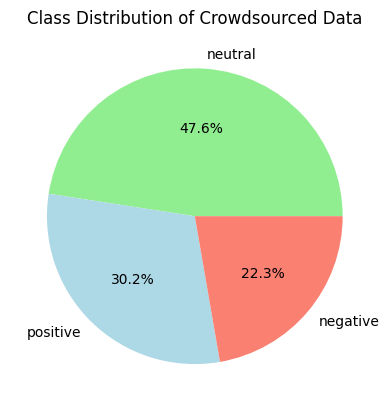

In [8]:
import matplotlib.pyplot as plt

df_crowdsourced_data['sentiment'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'lightblue', 'salmon'])

plt.title('Class Distribution of Crowdsourced Data')
plt.ylabel('')
plt.show()

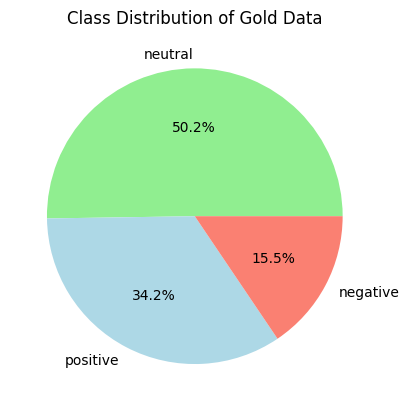

In [9]:
df_gold_data['sentiment'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'lightblue', 'salmon'])

plt.title('Class Distribution of Gold Data')
plt.ylabel('')
plt.show()

### Agreement between datasets

When we check the agreement score between two datasets with Cohen's kappa score, we got 0.4463 which is moderate agreement. It shows that while there is some level of consistency between the crowdsourced data and the gold data, there is also a noticeable degree of disagreement. This could influence the accuracy of the model. We showed the confusion matrix of the labels in two different datasets.

In [11]:
from sklearn.metrics import cohen_kappa_score

print(cohen_kappa_score(df_gold_data['sentiment'], df_crowdsourced_data['sentiment']))

0.44628451952213066


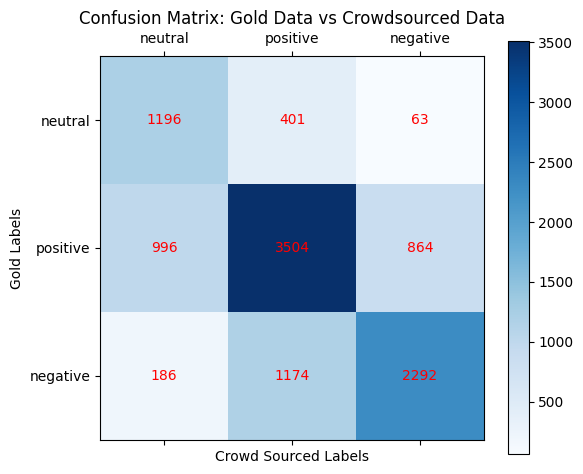

In [12]:
from sklearn.metrics import confusion_matrix
import numpy as np

conf_matrix = confusion_matrix(df_gold_data['sentiment'], df_crowdsourced_data['sentiment'])

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(conf_matrix, cmap='Blues')

fig.colorbar(cax)

ax.set_title('Confusion Matrix: Gold Data vs Crowdsourced Data')
ax.set_xlabel('Crowd Sourced Labels')
ax.set_ylabel('Gold Labels')

ax.set_xticks(np.arange(3))
ax.set_yticks(np.arange(3))
ax.set_xticklabels(['neutral', 'positive', 'negative'])
ax.set_yticklabels(['neutral', 'positive', 'negative'])

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', color='red')

plt.tight_layout()
plt.show()

## SVM Training

Below we prepared the data for SVM training, fine-tuned and trained the SVM. Then checked the performance on the test set.

### Data Cleaning for SVM

To clean the data to train SVM, we followed below steps:

**Lowercasing**: Convert all text to lowercase to avoid treating the same word in different cases (e.g., “Good” and “good”) as separate.

**Remove Special Characters and Punctuation**: Remove characters that don't contribute to the meaning of the text (e.g., punctuation marks, numbers, etc.).

**Tokenization**: Split the text into individual words (tokens). For SVM, this might not be necessary explicitly since TF-IDF handles the tokenization, but it’s useful to understand.

**Stopword Removal**: Remove common words (e.g., "and", "the", "is") that do not carry significant meaning. However, you may want to keep common words like “not” (which impacts sentiment).

**Lemmatization**: Convert words to their base or root form (e.g., "running" becomes "run"). This is often done using WordNetLemmatizer.

In [13]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /home/korhan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /home/korhan/nltk_data...


True

In [14]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_data_for_svm(df):
    df_new = df.copy()
    df_new['text'] = df_new['text'].str.lower()
    df_new['text'] = df_new['text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))
    df_new['text'] = df_new['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
    df_new['text'] = df_new['text'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))

    return df_new

### Feature Extraction and Hyperparameter Tuning for SVM

We converted text data into a numerical representation using TF-IDF (Term Frequency-Inverse Document Frequency). This approach focuses on the importance of words in a document relative to the entire corpus. Then we used grid search to fine the best hyperparameters for the selected dataset. Change the first parameter of the shuffle below to choose the dataset to train the model.

In [15]:
df_crowdsourced_svm = clean_data_for_svm(df_crowdsourced_data)
df_gold_svm = clean_data_for_svm(df_gold_data)
df_test_svm = clean_data_for_svm(df_test_data)

df_crowdsourced_svm.head()

,sentiment,text
0,positive,there much misconception islam rn showing musl...
1,positive,mrrondeau try iron maiden friday way bell ring...
2,negative,going fantasticfour tomorrow half expecting bo...
3,neutral,cfelan hey hey checkng see kokorissa interest ...
4,positive,anyone get drunk watch twilight best friend mo...


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.utils import shuffle

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm', SVC())
])

param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__max_df': [0.8, 0.9, 1.0],
    'tfidf__min_df': [1, 5],
    'tfidf__max_features': [1000, 3000, 5000],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']
}

# Train dataset selection.
# Change the first parameter of shuffle to either df_crowdsourced_svm or df_gold_svm.
train_data_svm = shuffle(df_gold_svm, random_state=12345)

In [21]:
X_train_svm = train_data_svm['text']
y_train_svm = train_data_svm['sentiment']

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', verbose=1)
grid.fit(X_train_svm, y_train_svm)

print("Best parameters found:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best parameters found: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf', 'tfidf__max_df': 0.8, 'tfidf__max_features': 3000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 1)}
Best cross-validation score: 0.5755002507395097


In [24]:
from sklearn.metrics import classification_report

X_test = df_test_svm['text']
y_test = df_test_svm['sentiment']

y_pred_svm = grid.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred_svm, target_names=['negative', 'neutral', 'positive']))

              precision    recall  f1-score   support

    negative       0.84      0.65      0.73      1077
     neutral       0.74      0.90      0.81      2597
    positive       0.86      0.72      0.78      1850

    accuracy                           0.79      5524
   macro avg       0.82      0.75      0.78      5524
weighted avg       0.80      0.79      0.79      5524



## DistilBERT Training

We trained DistilBERT model as well to make comparison between two different models. Below code cell tokenizes the text in the dataset. We used AutoTokenizer with distilbert-base-uncased configuration.

In [27]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from datasets import Dataset

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

label_to_int = {"negative": 0, "neutral": 1, "positive": 2}
int_to_label = {0: "negative", 1: "neutral", 2: "positive"}

def tokenize_function(examples):
    tokenized_batch = tokenizer(examples["text"], padding="max_length", truncation=True)
    tokenized_batch["label"] = [label_to_int[label] for label in examples["label"]]
    return tokenized_batch

def get_tokenized_datasets_from_dataframes(df_train, df_test):
    X_train, X_val, y_train, y_val = \
    train_test_split(df_train['text'], df_train['sentiment'], test_size=0.2, random_state=12345)
    
    train_dataset = Dataset.from_dict({"text": X_train, "label": y_train}, split="train")
    val_dataset = Dataset.from_dict({"text": X_val, "label": y_val}, split="val")
    test_dataset = Dataset.from_dict({"text": df_test['text'], "label": df_test['sentiment']}, split="test")
    
    tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True).remove_columns(["text"]).rename_column("label", "labels")
    tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True).remove_columns(["text"]).rename_column("label", "labels")
    tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True).remove_columns(["text"]).rename_column("label", "labels")
    
    tokenized_train_dataset.set_format("torch")
    tokenized_val_dataset.set_format("torch")
    tokenized_test_dataset.set_format("torch")

    return tokenized_train_dataset, tokenized_val_dataset, tokenized_test_dataset

In [28]:
crowdsourced_tokenized_train_dataset, crowdsourced_tokenized_val_dataset, crowdsourced_tokenized_test_dataset = \
get_tokenized_datasets_from_dataframes(df_crowdsourced_data, df_test_data)

gold_tokenized_train_dataset, gold_tokenized_val_dataset, gold_tokenized_test_dataset = \
get_tokenized_datasets_from_dataframes(df_gold_data, df_test_data)

Map:   0%|          | 0/8540 [00:00<?, ? examples/s]

Map:   0%|          | 0/2136 [00:00<?, ? examples/s]

Map:   0%|          | 0/5524 [00:00<?, ? examples/s]

Map:   0%|          | 0/8540 [00:00<?, ? examples/s]

Map:   0%|          | 0/2136 [00:00<?, ? examples/s]

Map:   0%|          | 0/5524 [00:00<?, ? examples/s]

### Performance evaluation

Below function evaluates the performance of the model for the given dataset. It returns accuracy, F1-score, precision and recall with macro averaging and the predicted labels.

In [33]:
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def evaluate_model(model, dataloader):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            with torch.no_grad():
                outputs = model(**batch)

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)
            preds.extend(predictions.detach().tolist())
            accuracy_metric.add_batch(predictions=predictions, references=batch["labels"])
            f1_metric.add_batch(predictions=predictions, references=batch["labels"])
            precision_metric.add_batch(predictions=predictions, references=batch["labels"])
            recall_metric.add_batch(predictions=predictions, references=batch["labels"])

    result = {"accuracy": accuracy_metric.compute()["accuracy"],
              "f1": f1_metric.compute(average='macro')["f1"],
              "precision": precision_metric.compute(average='macro')["precision"],
              "recall": recall_metric.compute(average='macro')["recall"]}
                
    model.train()
    return result, preds

### Hyperparameter tuning

Before start training, tune the below hyperparameters. We tried different learning rate and epoch numbers with both training datasets to find the optimal hyperparameters for this task.

In [29]:
# Tune these hyperparameters before you start training
lr = 5e-5 # Learning rate. Choose among 3e-5, 4e-5, 5e-5
num_epochs = 2 # Number of epochs. Choose among 2, 3, 4

# Datasets to be used in training and validation
# Choose either crowdsourced_tokenized_train_dataset or gold_tokenized_train_dataset
tokenized_train_dataset = gold_tokenized_train_dataset
# Choose either crowdsourced_tokenized_val_dataset or gold_tokenized_val_dataset
tokenized_val_dataset = crowdsourced_tokenized_val_dataset

### Model definition

In the below cell, we define the model with optimizer and hyperparameters and preparing it for the training.

In [31]:
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_scheduler
import torch
from torch.utils.data import DataLoader

model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

train_dataloader = DataLoader(tokenized_train_dataset, shuffle=True, batch_size=32)
val_dataloader = DataLoader(tokenized_val_dataset, batch_size=32)

optimizer = AdamW(model.parameters(), lr=lr)
num_training_steps = num_epochs * len(train_dataloader)
lr_scheduler = get_scheduler(
    name="linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


### Model training

Below cell trains the model. It uses validation dataset to evaulate the model during the training.

In [34]:
from tqdm.auto import tqdm

progress_bar = tqdm(range(num_training_steps))
steps_between_eval = int(num_training_steps/10)

model.train()
num_steps = 0
for epoch in range(num_epochs):
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)
        num_steps += 1

        if num_steps % steps_between_eval == 0:
            result, _ = evaluate_model(model, val_dataloader)
            tqdm.write(f"Step {num_steps}")
            tqdm.write(f"\tTrain loss: {loss}")
            tqdm.write(f"\tEvaluation scores: {result}")

  0%|          | 0/534 [00:00<?, ?it/s]

Step 53
	Train loss: 0.5110112428665161
	Evaluation scores: {'accuracy': 0.6254681647940075, 'f1': 0.5903411066901756, 'precision': 0.6110311058102562, 'recall': 0.5792358362228563}
Step 106
	Train loss: 0.6532555818557739
	Evaluation scores: {'accuracy': 0.6104868913857678, 'f1': 0.5908419619180832, 'precision': 0.594901488661151, 'recall': 0.5926626571337977}
Step 159
	Train loss: 0.5776015520095825
	Evaluation scores: {'accuracy': 0.6198501872659176, 'f1': 0.5637746450747293, 'precision': 0.630935550813847, 'recall': 0.5561216975052932}
Step 212
	Train loss: 0.6898102760314941
	Evaluation scores: {'accuracy': 0.6226591760299626, 'f1': 0.6048730994145949, 'precision': 0.6088804093661754, 'recall': 0.6074498552681376}
Step 265
	Train loss: 0.5400165915489197
	Evaluation scores: {'accuracy': 0.6221910112359551, 'f1': 0.5916219278277809, 'precision': 0.6148152664612759, 'recall': 0.5849974940419568}
Step 318
	Train loss: 0.25838524103164673
	Evaluation scores: {'accuracy': 0.62406367041

### Evaluation

Below, evaluation of the trained model on the test set is done. It prints accuracy, F1-score, precision and recall achieved on the test set. Also prints the confusion matrix.

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_dataloader = DataLoader(gold_tokenized_test_dataset, batch_size=32)
result, preds = evaluate_model(model, test_dataloader)

true_labels = []
for batch in test_dataloader:
    true_labels.extend(batch['labels'].numpy())  

labels = sorted(set(true_labels))
cm = confusion_matrix(true_labels, preds, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"True: {label}" for label in labels],
                        columns=[f"Pred: {label}" for label in labels])

print(result)
print(cm_df)

{'accuracy': 0.780955829109341, 'f1': 0.7764610163536733, 'precision': 0.7796015645032343, 'recall': 0.773705699547173}
         Pred: 0  Pred: 1  Pred: 2
True: 0      801      248       28
True: 1      222     2068      307
True: 2       35      370     1445


## Trivial Baseline Model

We used Dummy Classifier as baseline model which always classifies the most frequent class.

In [36]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(df_gold_data['text'], df_gold_data['sentiment'])
y_pred = dummy_clf.predict(df_test_data['text'])

print(accuracy_score(df_test_data['sentiment'], y_pred))

0.470130340333092
